# YOLO26n baseline — parking space occupancy detection

This notebook summarizes the baseline model prepared for the Neural Networks project.

The task is **two-class object detection** on parking lot images:

- `space-empty`
- `space-occupied`

The model predicts bounding boxes around parking spaces and classifies each detected space as empty or occupied.

## 1. Project goal

The goal of the baseline is to build a simple, reproducible reference model for parking space detection and occupancy classification.

Given an input image of a parking lot, the model should return:

- bounding boxes for visible parking spaces,
- class label for each box: `space-empty` or `space-occupied`,
- confidence score for each prediction.

We use a pretrained **YOLO26n** model and fine-tune it on the PKLot dataset converted to YOLO format.

## 2. Dataset

The dataset was downloaded from Kaggle/Roboflow and originally provided annotations in COCO format.

The raw dataset split contained:

| Split | Images | Annotations |
|---|---:|---:|
| Train | 8691 | 497856 |
| Validation | 2483 | 143316 |
| Test | 1242 | 70684 |

The original COCO categories were:

| COCO category id | Name |
|---:|---|
| 0 | `spaces` |
| 1 | `space-empty` |
| 2 | `space-occupied` |

Category `0` was a parent/placeholder category and was not used as a training class.

## 3. Dataset inspection and preprocessing decisions

During dataset inspection, the bounding boxes were generally correct. However, approximately 2% of images had **zero annotations** despite some of them visibly containing parking spaces.

Zero-annotation images:

| Split | Zero-annotation images | Percentage |
|---|---:|---:|
| Train | 189 / 8691 | 2.17% |
| Validation | 59 / 2483 | 2.38% |
| Test | 26 / 1242 | 2.09% |

These images were skipped during conversion to YOLO format. Keeping them would incorrectly teach the detector that visible parking spaces are background.

We also observed occasional noisy `empty`/`occupied` labels, but these were not filtered automatically.

## 4. COCO → YOLO conversion

The dataset was converted from COCO format to YOLO format.

Class mapping:

| COCO category id | COCO class | YOLO class id | YOLO class |
|---:|---|---:|---|
| 1 | `space-empty` | 0 | `space-empty` |
| 2 | `space-occupied` | 1 | `space-occupied` |

YOLO label format:

```text
class_id x_center y_center width height
```

where coordinates are normalized to `[0, 1]`.

Final converted dataset:

| Split | Images kept | Labels |
|---|---:|---:|
| Train | 8502 | 497856 |
| Validation | 2424 | 143316 |
| Test | 1216 | 70684 |

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Image, display

FINAL_RESULTS_DIR = Path("../outputs/final_results")
PLOTS_DIR = FINAL_RESULTS_DIR / "plots"
PREDICTIONS_DIR = FINAL_RESULTS_DIR / "predictions"

print("Final results directory:", FINAL_RESULTS_DIR.resolve())

Final results directory: /Users/jan/Documents/Studia/Neuronki/parking-spaces-classifier/outputs/final_results


## 5. Model

The baseline model is **YOLO26n**, initialized from pretrained weights:

```text
yolo26n.pt
```

The model was adapted to two classes:

- `space-empty`
- `space-occupied`

This is still a single baseline model. It performs both detection and occupancy classification in one forward pass.

## 6. Training setup

Final training configuration:

| Parameter | Value |
|---|---|
| Model | YOLO26n |
| Pretrained weights | `yolo26n.pt` |
| Image size | 768 |
| Batch size | 8 |
| Planned epochs | 35 |
| Completed validated epochs | 7 |
| Device | MPS, Apple M3 Max |
| Optimizer | AdamW, selected automatically by Ultralytics |
| Seed | 42 |

The training process was interrupted after epoch 8 with exit code `137`, which indicates the process was likely killed due to memory pressure / out-of-memory. The last fully validated epoch was epoch 7.

The final model used for evaluation is:

```text
runs/detect/yolo26n_pklot_768_b8_e35/weights/best.pt
```

## 7. Training command

```bash
time uv run yolo detect train \
  model=yolo26n.pt \
  data=data/yolo/data.yaml \
  imgsz=768 \
  epochs=35 \
  batch=8 \
  device=mps \
  workers=0 \
  cache=False \
  patience=10 \
  save_period=5 \
  seed=42 \
  name=yolo26n_pklot_768_b8_e35 \
  exist_ok=True
```

## 8. Training progress

The best validation result was achieved at epoch 7.

| Metric | Value |
|---|---:|
| Precision | 0.96636 |
| Recall | 0.96952 |
| mAP@50 | 0.99195 |
| mAP@50-95 | 0.86523 |

In [2]:
training_csv = FINAL_RESULTS_DIR / "training_results.csv"

if training_csv.exists():
    df = pd.read_csv(training_csv)
    df.columns = [col.strip() for col in df.columns]
    display(df)
else:
    print(f"Missing file: {training_csv}")

,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2
0,1,1411.31,1.42583,1.52806,0.00449,0.87718,0.88769,0.94070,0.66577,1.09162,0.68854,0.00431,0.000555,0.000555,0.000555
1,2,3177.08,1.09118,0.66401,0.00322,0.92221,0.93357,0.97011,0.73320,0.91590,0.43640,0.00348,0.001079,0.001079,0.001079
2,3,6183.67,0.99552,0.52372,0.00290,0.93823,0.93782,0.97090,0.77122,0.80089,0.36001,0.00296,0.001572,0.001572,0.001572
3,4,13952.90,0.91763,0.44388,0.00262,0.94152,0.95404,0.98558,0.82240,0.67471,0.29375,0.00253,0.001526,0.001526,0.001526
4,5,16548.00,0.84421,0.39949,0.00236,0.93682,0.94694,0.98658,0.84655,0.59277,0.26504,0.00216,0.001478,0.001478,0.001478
5,6,19346.20,0.80528,0.37442,0.00228,0.94545,0.95313,0.98719,0.85346,0.58855,0.25473,0.00220,0.001431,0.001431,0.001431
6,7,22120.40,0.76028,0.34427,0.00212,0.96636,0.96952,0.99195,0.86523,0.56066,0.22033,0.00206,0.001384,0.001384,0.001384


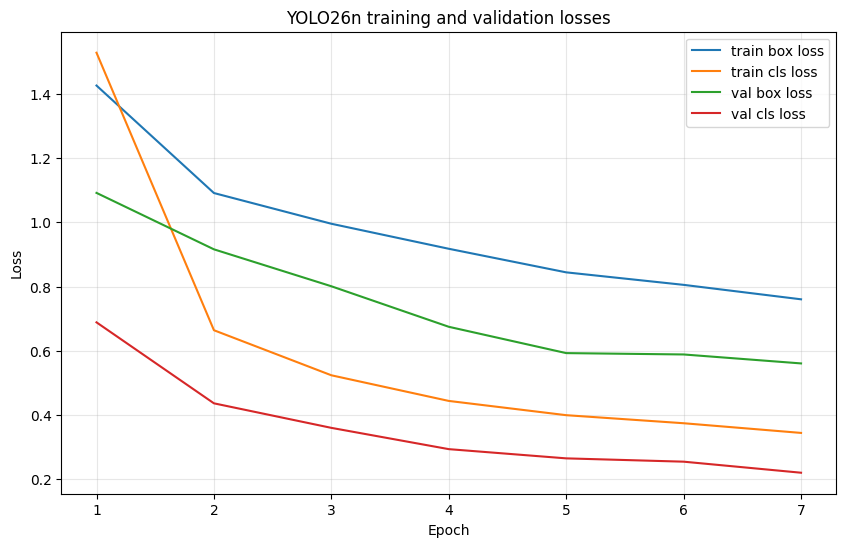

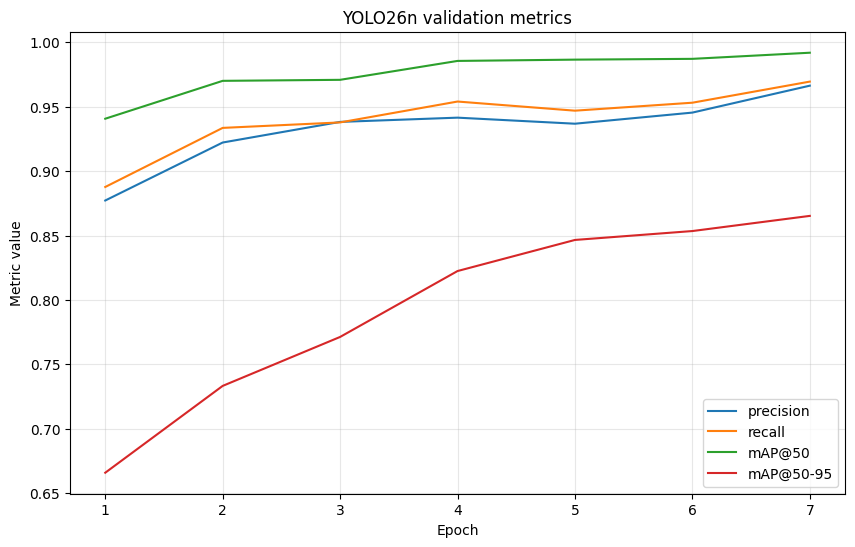

In [3]:
if training_csv.exists():
    df = pd.read_csv(training_csv)
    df.columns = [col.strip() for col in df.columns]

    plt.figure(figsize=(10, 6))
    plt.plot(df["epoch"], df["train/box_loss"], label="train box loss")
    plt.plot(df["epoch"], df["train/cls_loss"], label="train cls loss")
    plt.plot(df["epoch"], df["val/box_loss"], label="val box loss")
    plt.plot(df["epoch"], df["val/cls_loss"], label="val cls loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("YOLO26n training and validation losses")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    plt.figure(figsize=(10, 6))
    plt.plot(df["epoch"], df["metrics/precision(B)"], label="precision")
    plt.plot(df["epoch"], df["metrics/recall(B)"], label="recall")
    plt.plot(df["epoch"], df["metrics/mAP50(B)"], label="mAP@50")
    plt.plot(df["epoch"], df["metrics/mAP50-95(B)"], label="mAP@50-95")
    plt.xlabel("Epoch")
    plt.ylabel("Metric value")
    plt.title("YOLO26n validation metrics")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

## 9. Test set evaluation

Final test results were computed using `best.pt` on the test split.

| Class | Images | Instances | Precision | Recall | mAP@50 | mAP@50-95 |
|---|---:|---:|---:|---:|---:|---:|
| all | 1216 | 70684 | 0.967 | 0.969 | 0.991 | 0.866 |
| space-empty | 1041 | 36584 | 0.951 | 0.986 | 0.991 | 0.878 |
| space-occupied | 991 | 34100 | 0.982 | 0.951 | 0.992 | 0.854 |

Inference speed:

| Stage | Time per image |
|---|---:|
| Preprocess | 0.4 ms |
| Inference | 4.2 ms |
| Postprocess | 0.8 ms |

## 10. Test evaluation command

```bash
uv run yolo detect val \
  model=runs/detect/yolo26n_pklot_768_b8_e35/weights/best.pt \
  data=data/yolo/data.yaml \
  split=test \
  imgsz=768 \
  batch=8 \
  device=mps \
  workers=0 \
  name=yolo26n_pklot_768_b8_e35_test
```

## 11. Evaluation plots

The following plots were generated by Ultralytics during test evaluation.

test_confusion_matrix.png


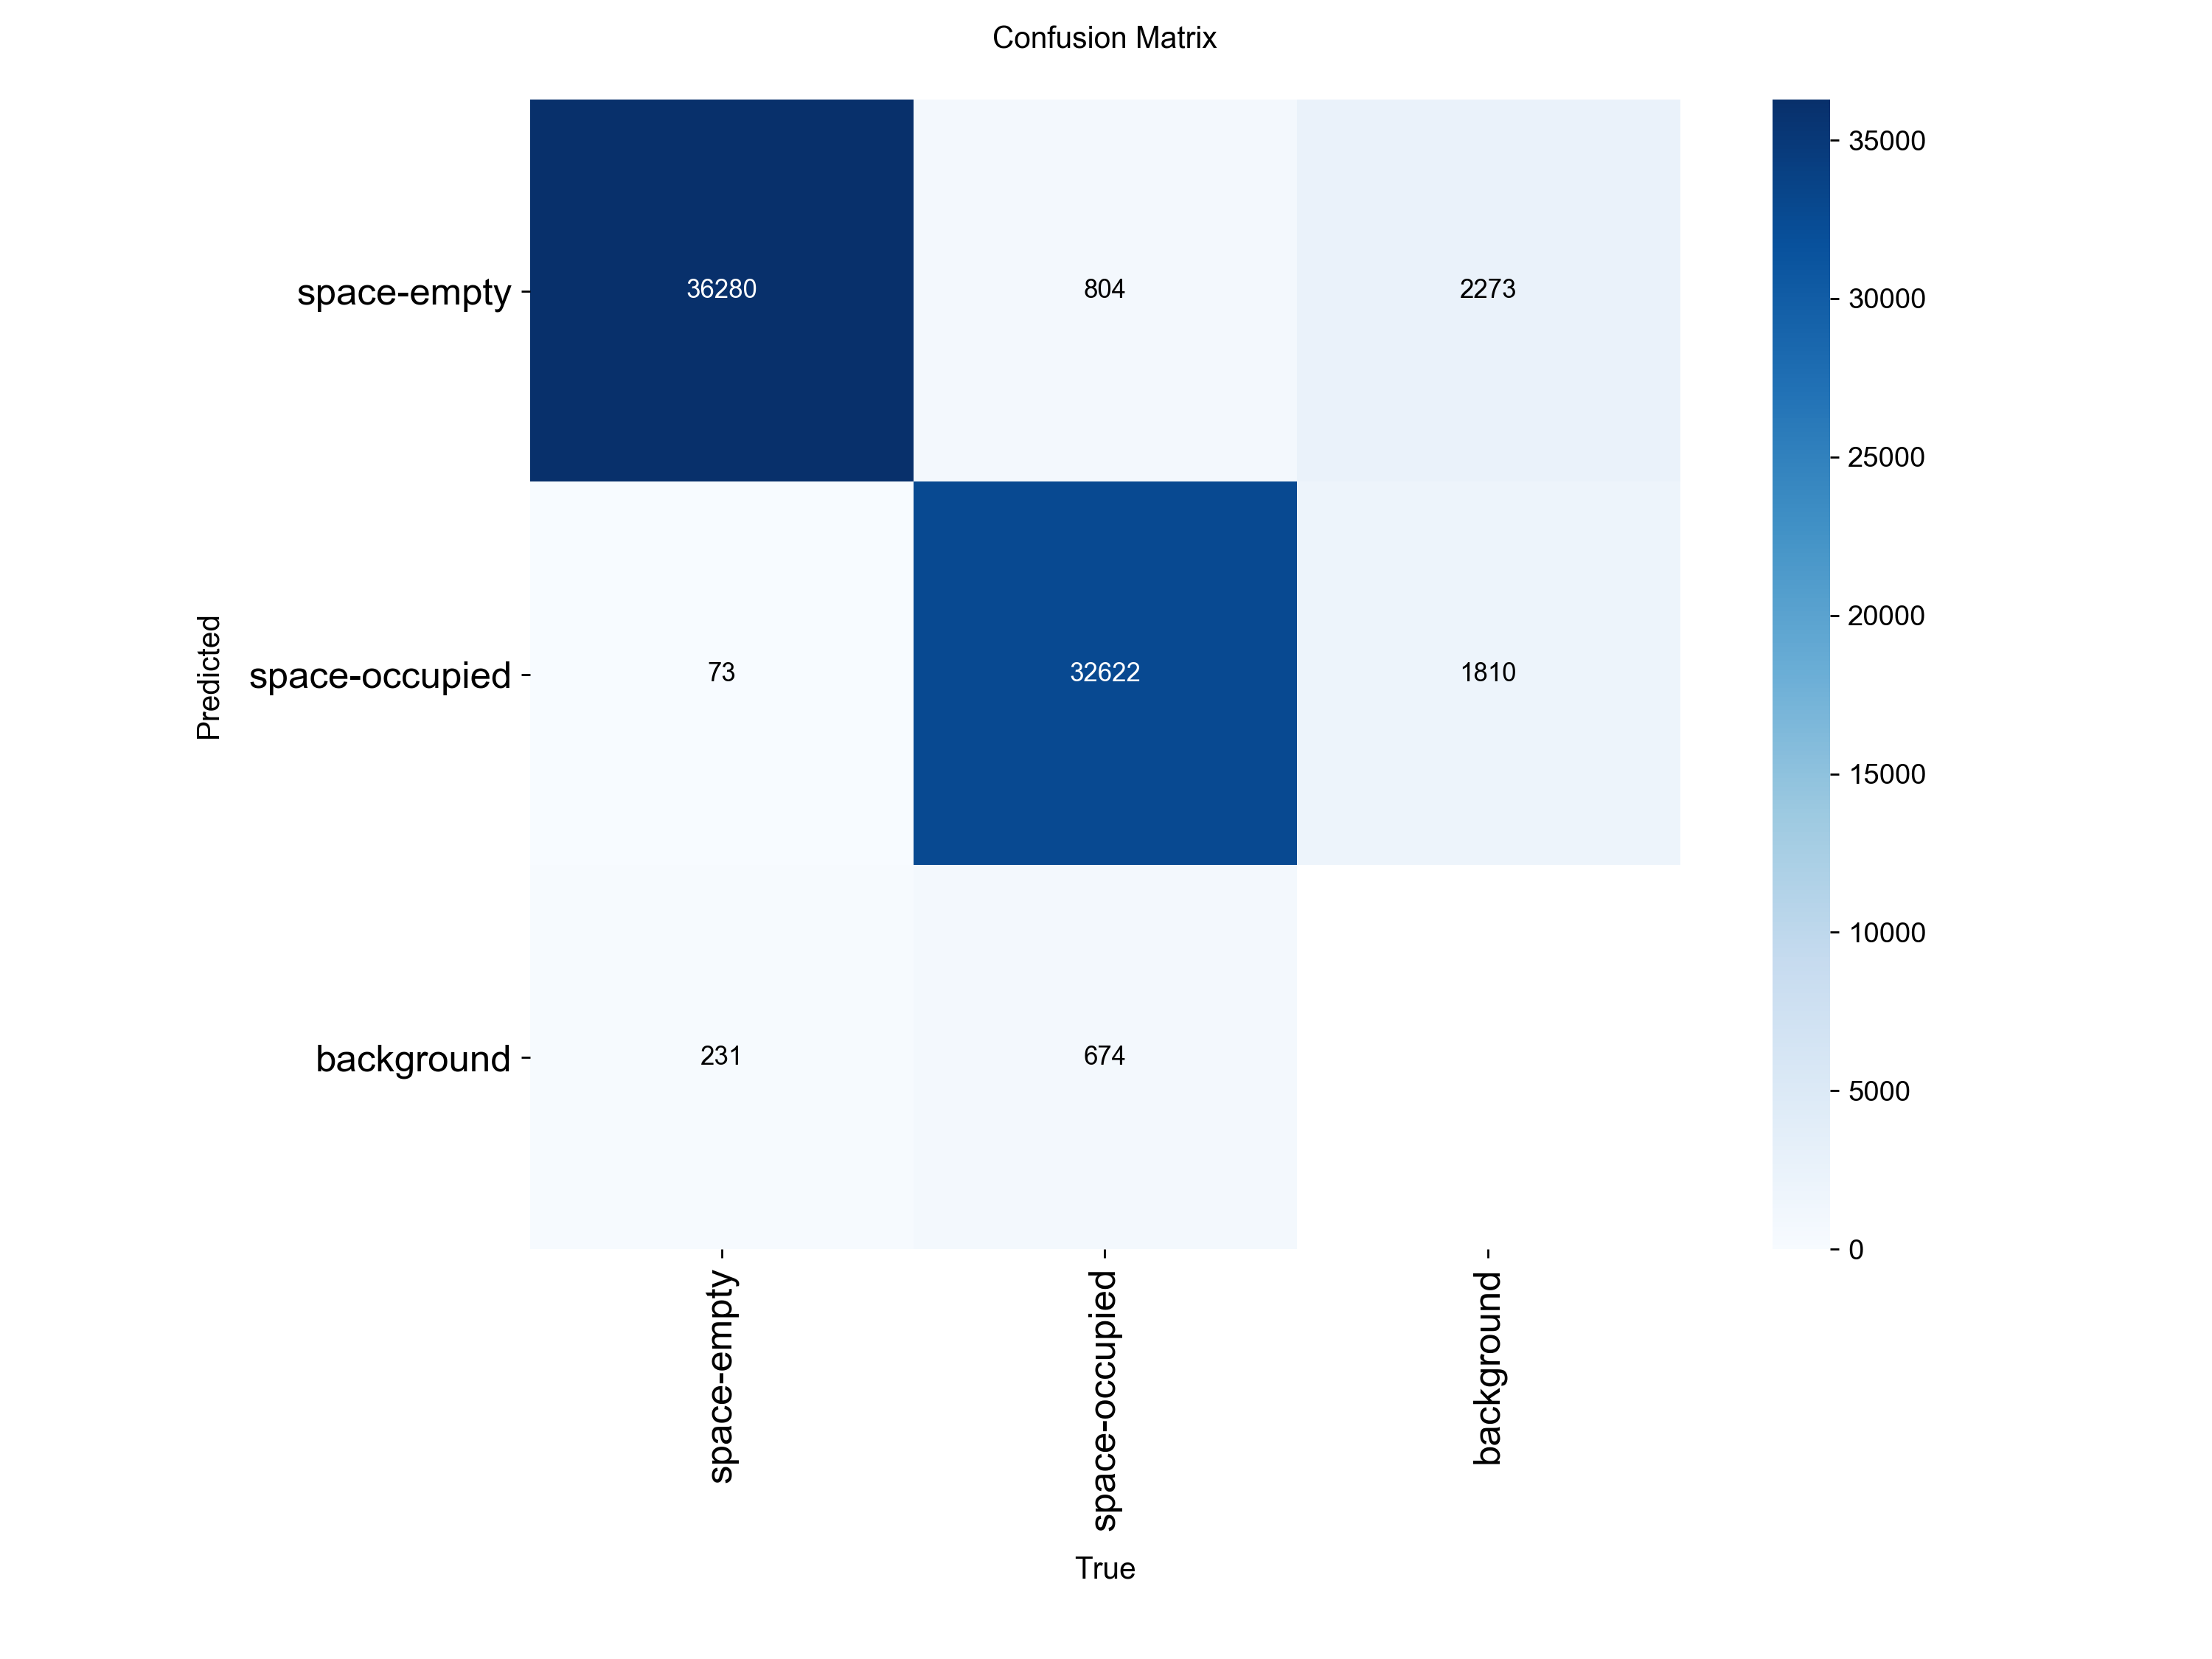

test_confusion_matrix_normalized.png


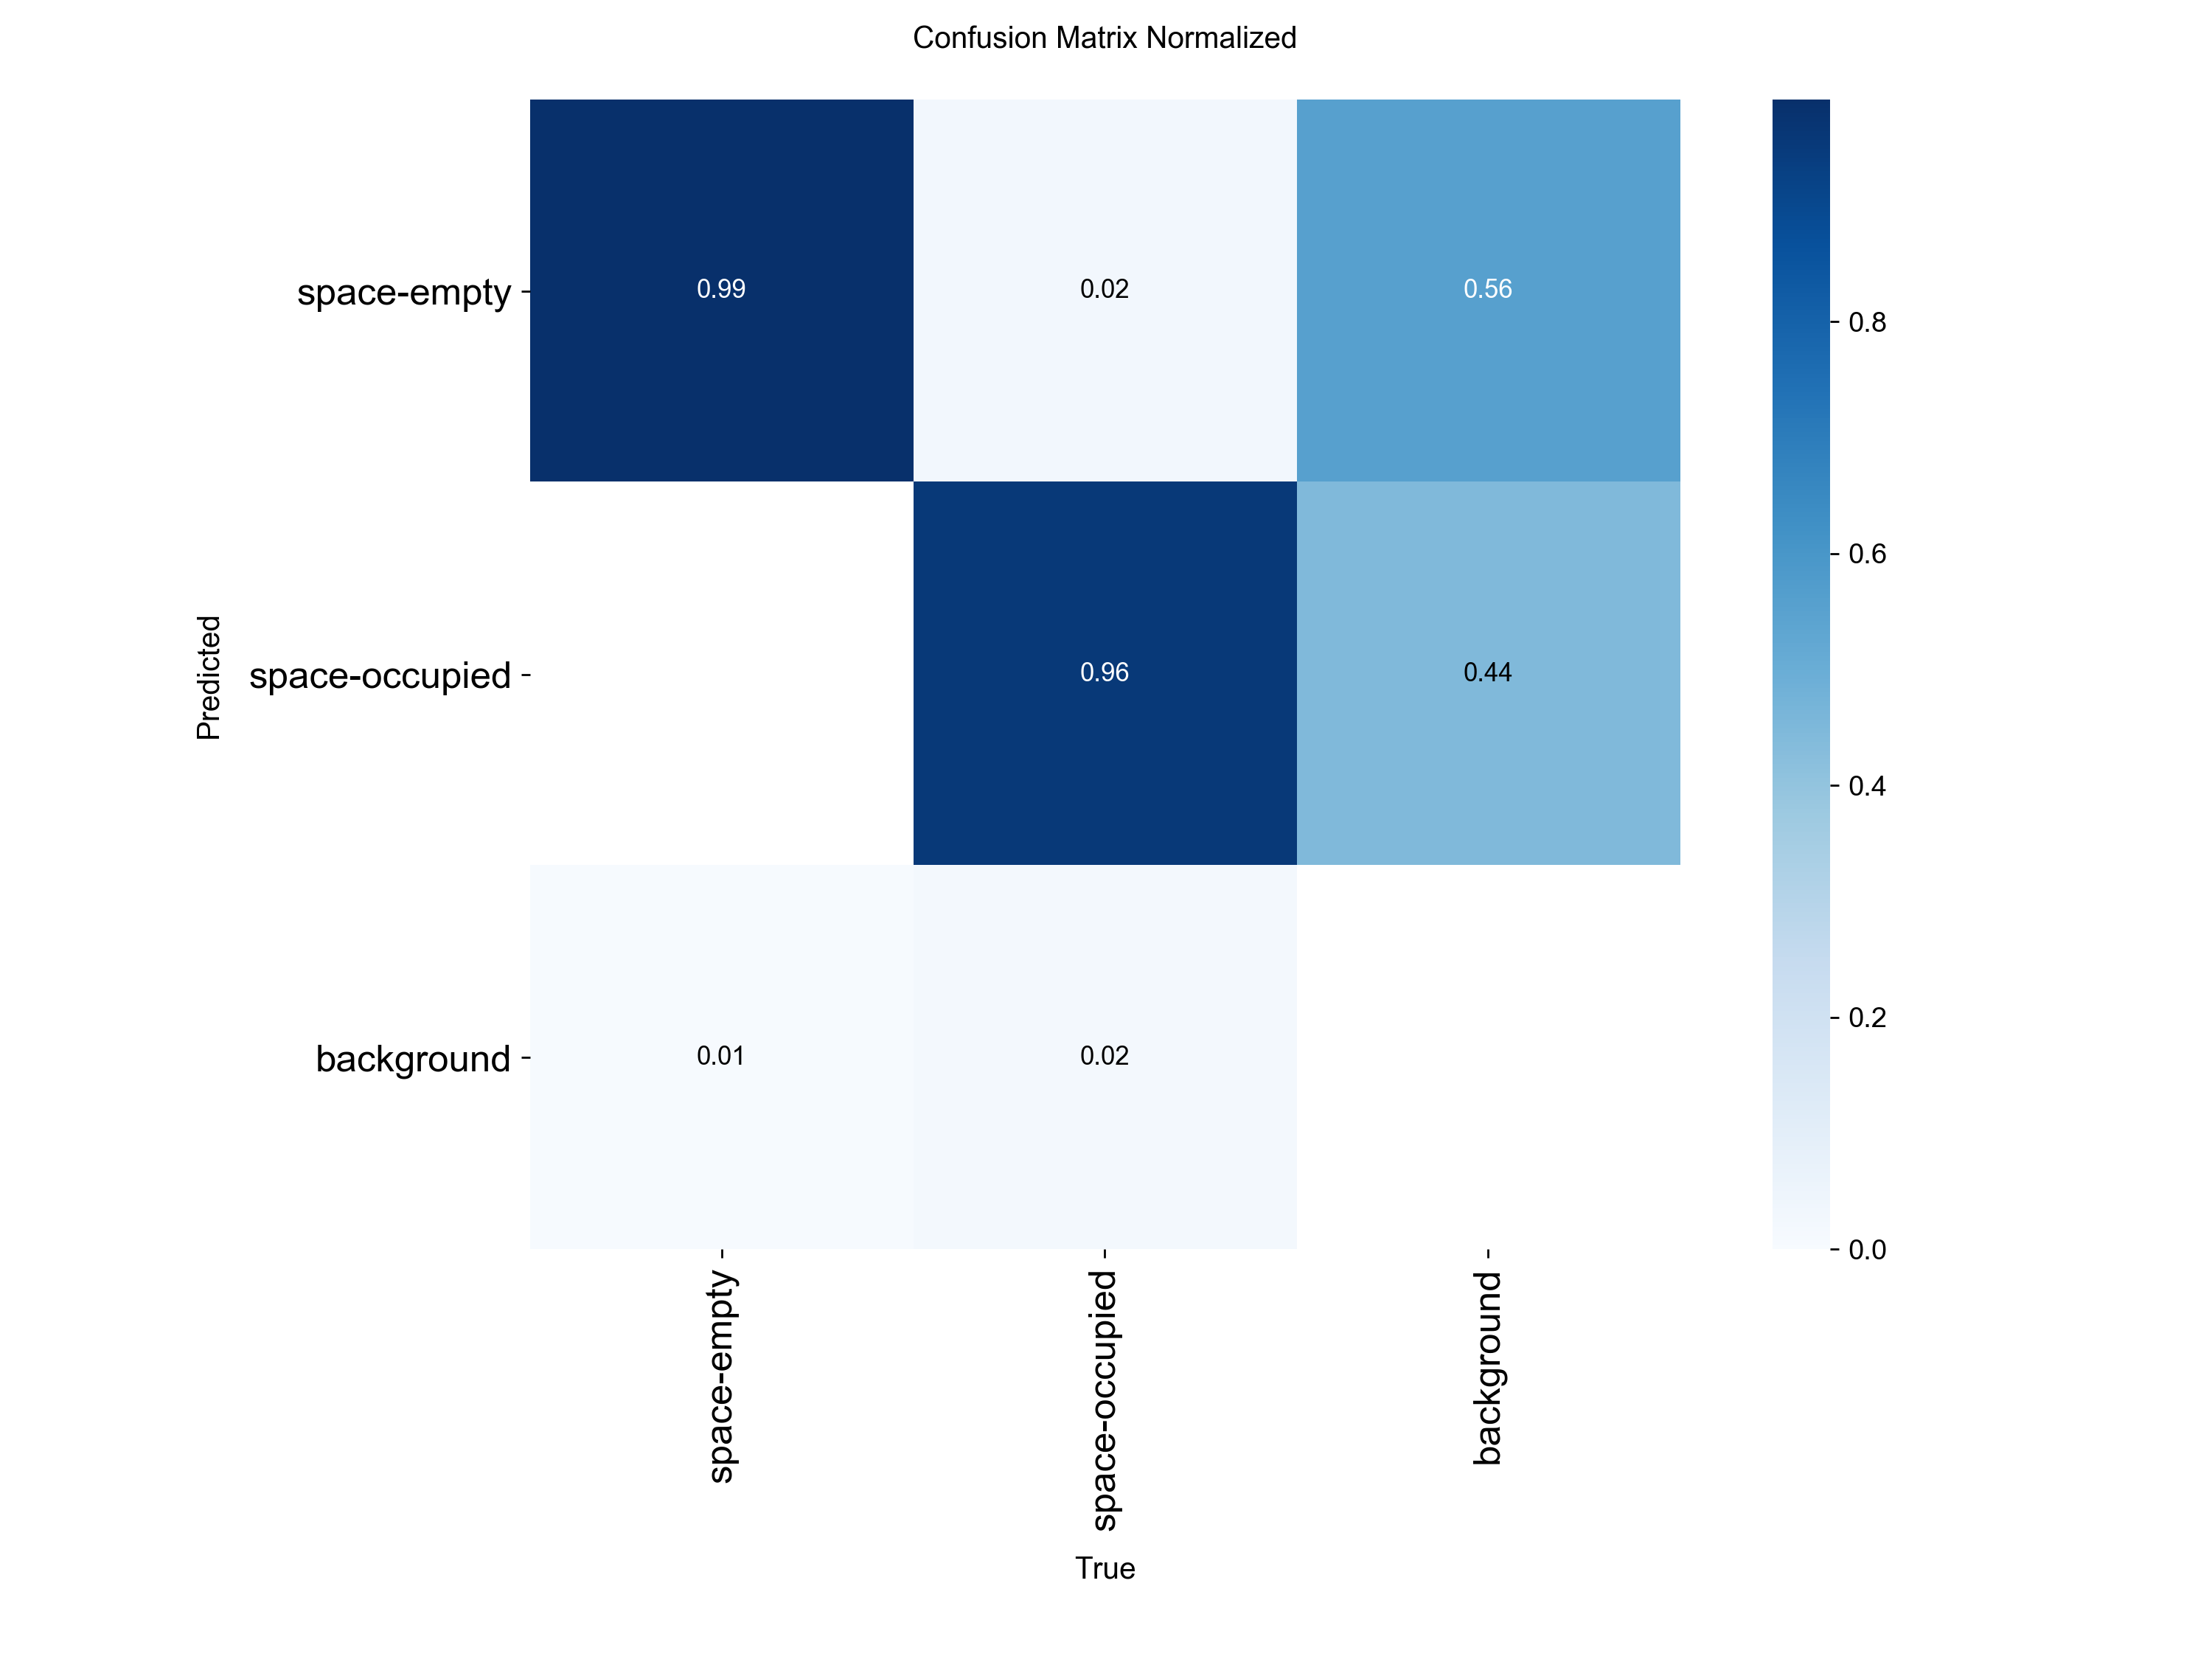

test_pr_curve.png


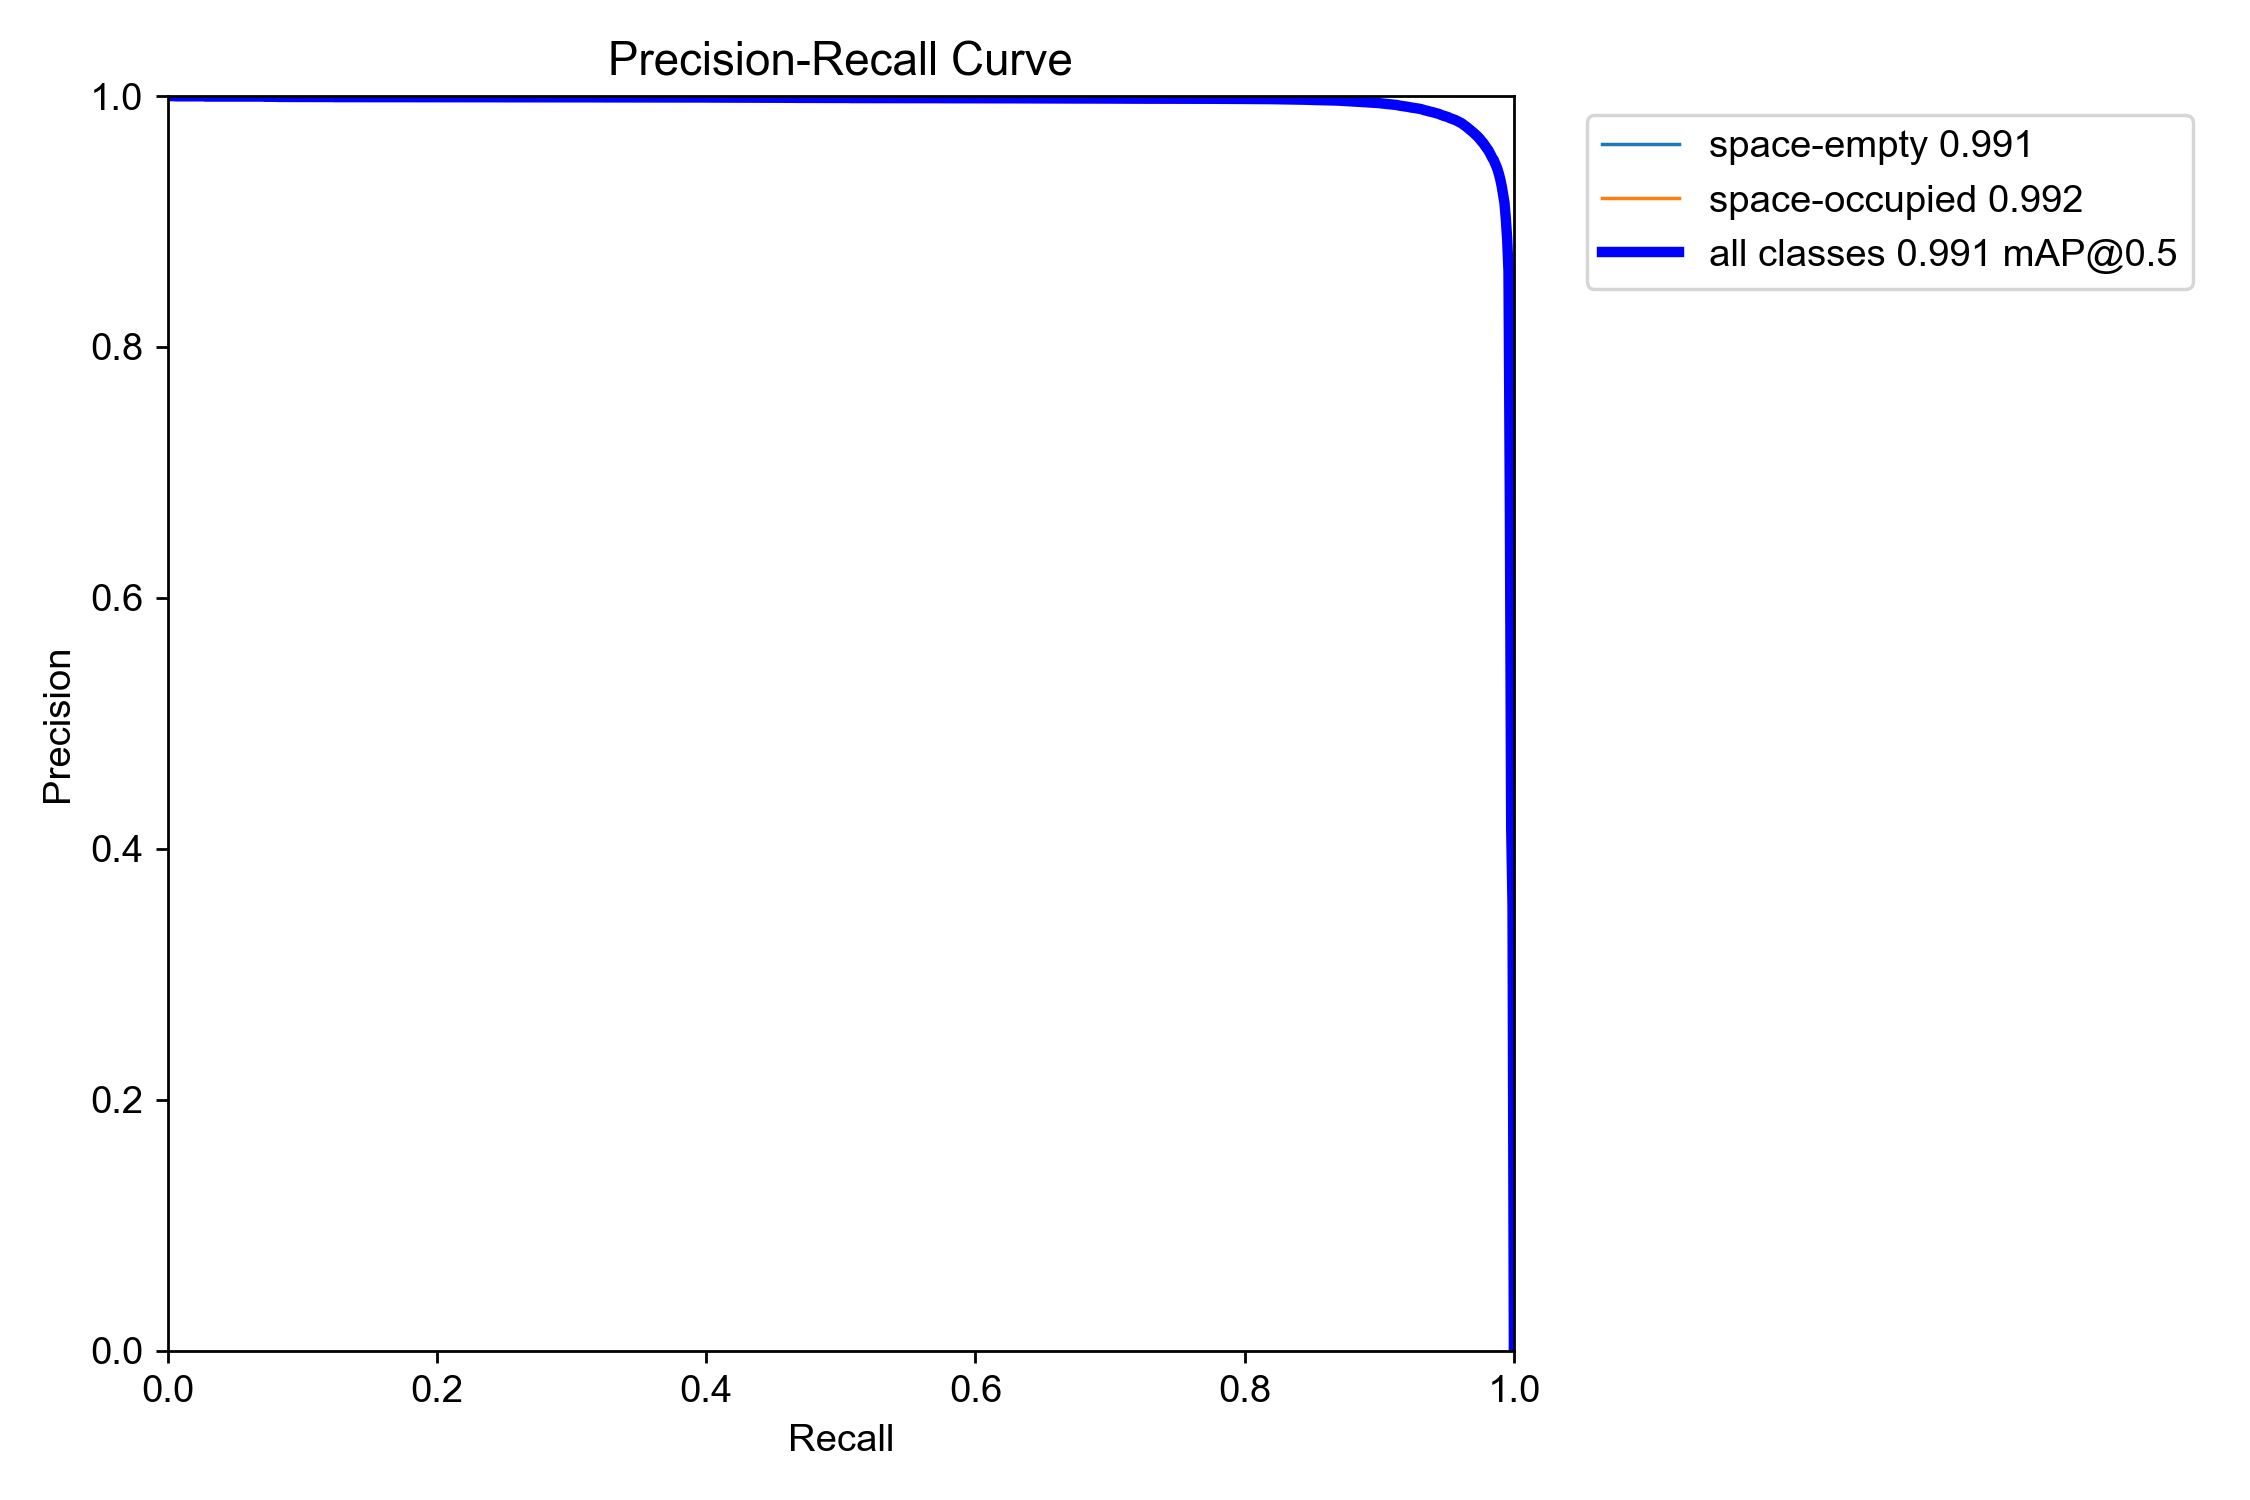

test_f1_curve.png


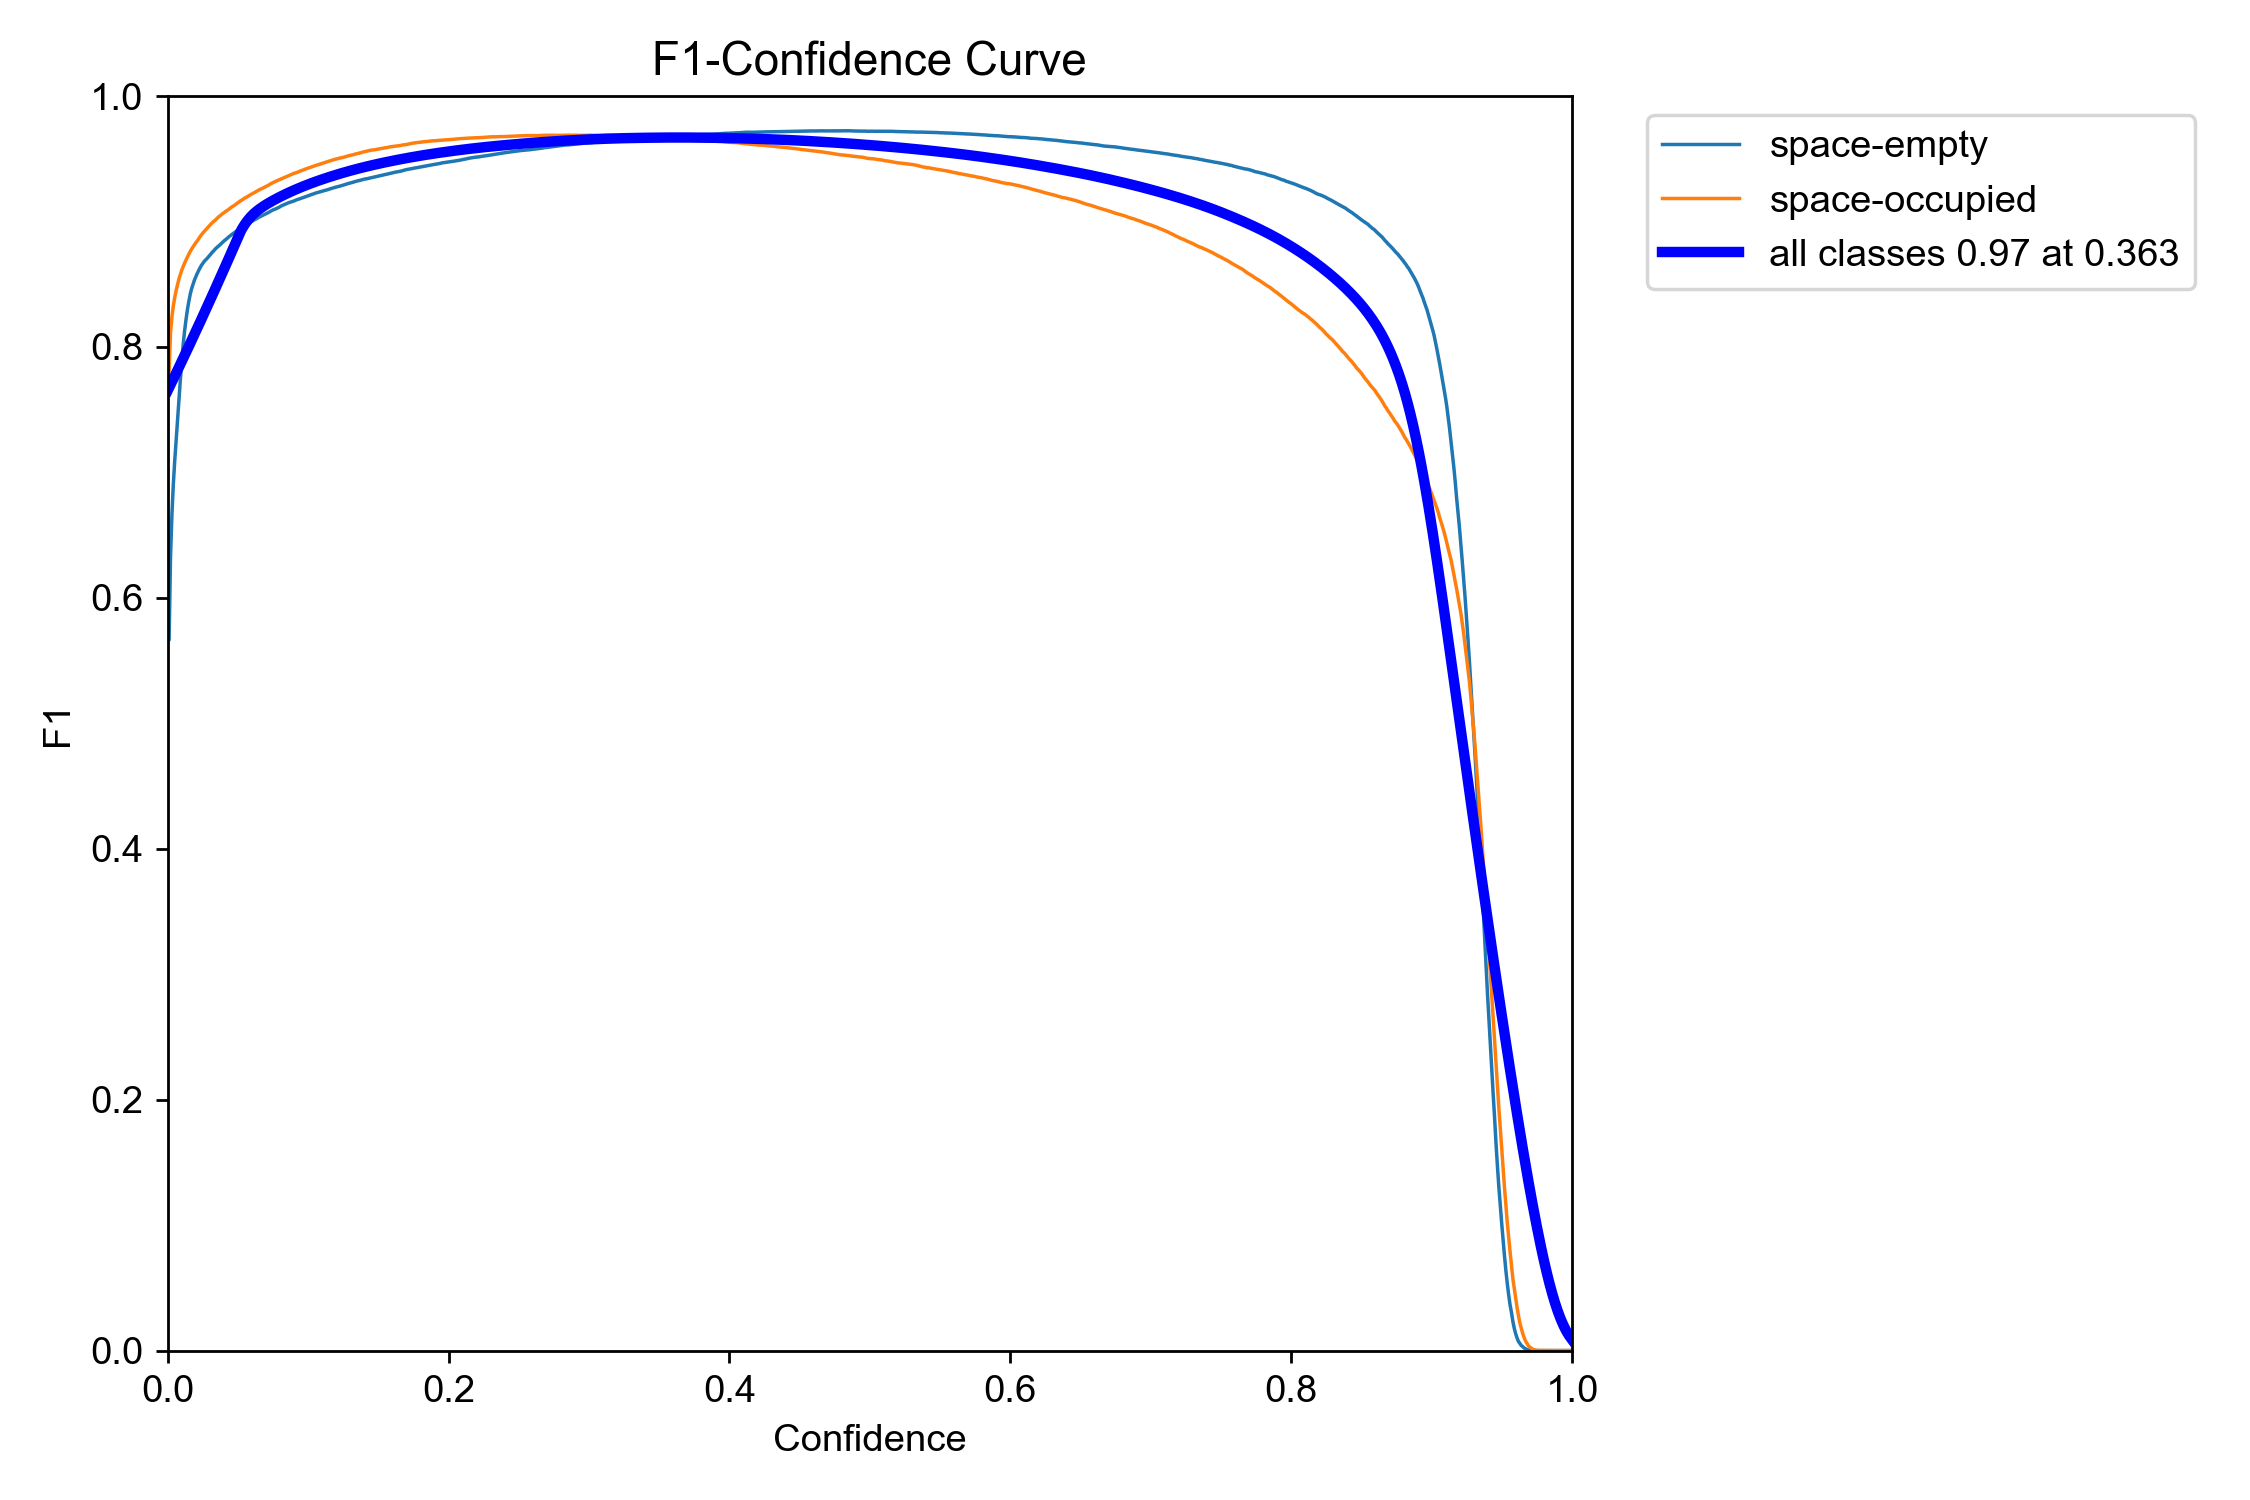

test_precision_curve.png


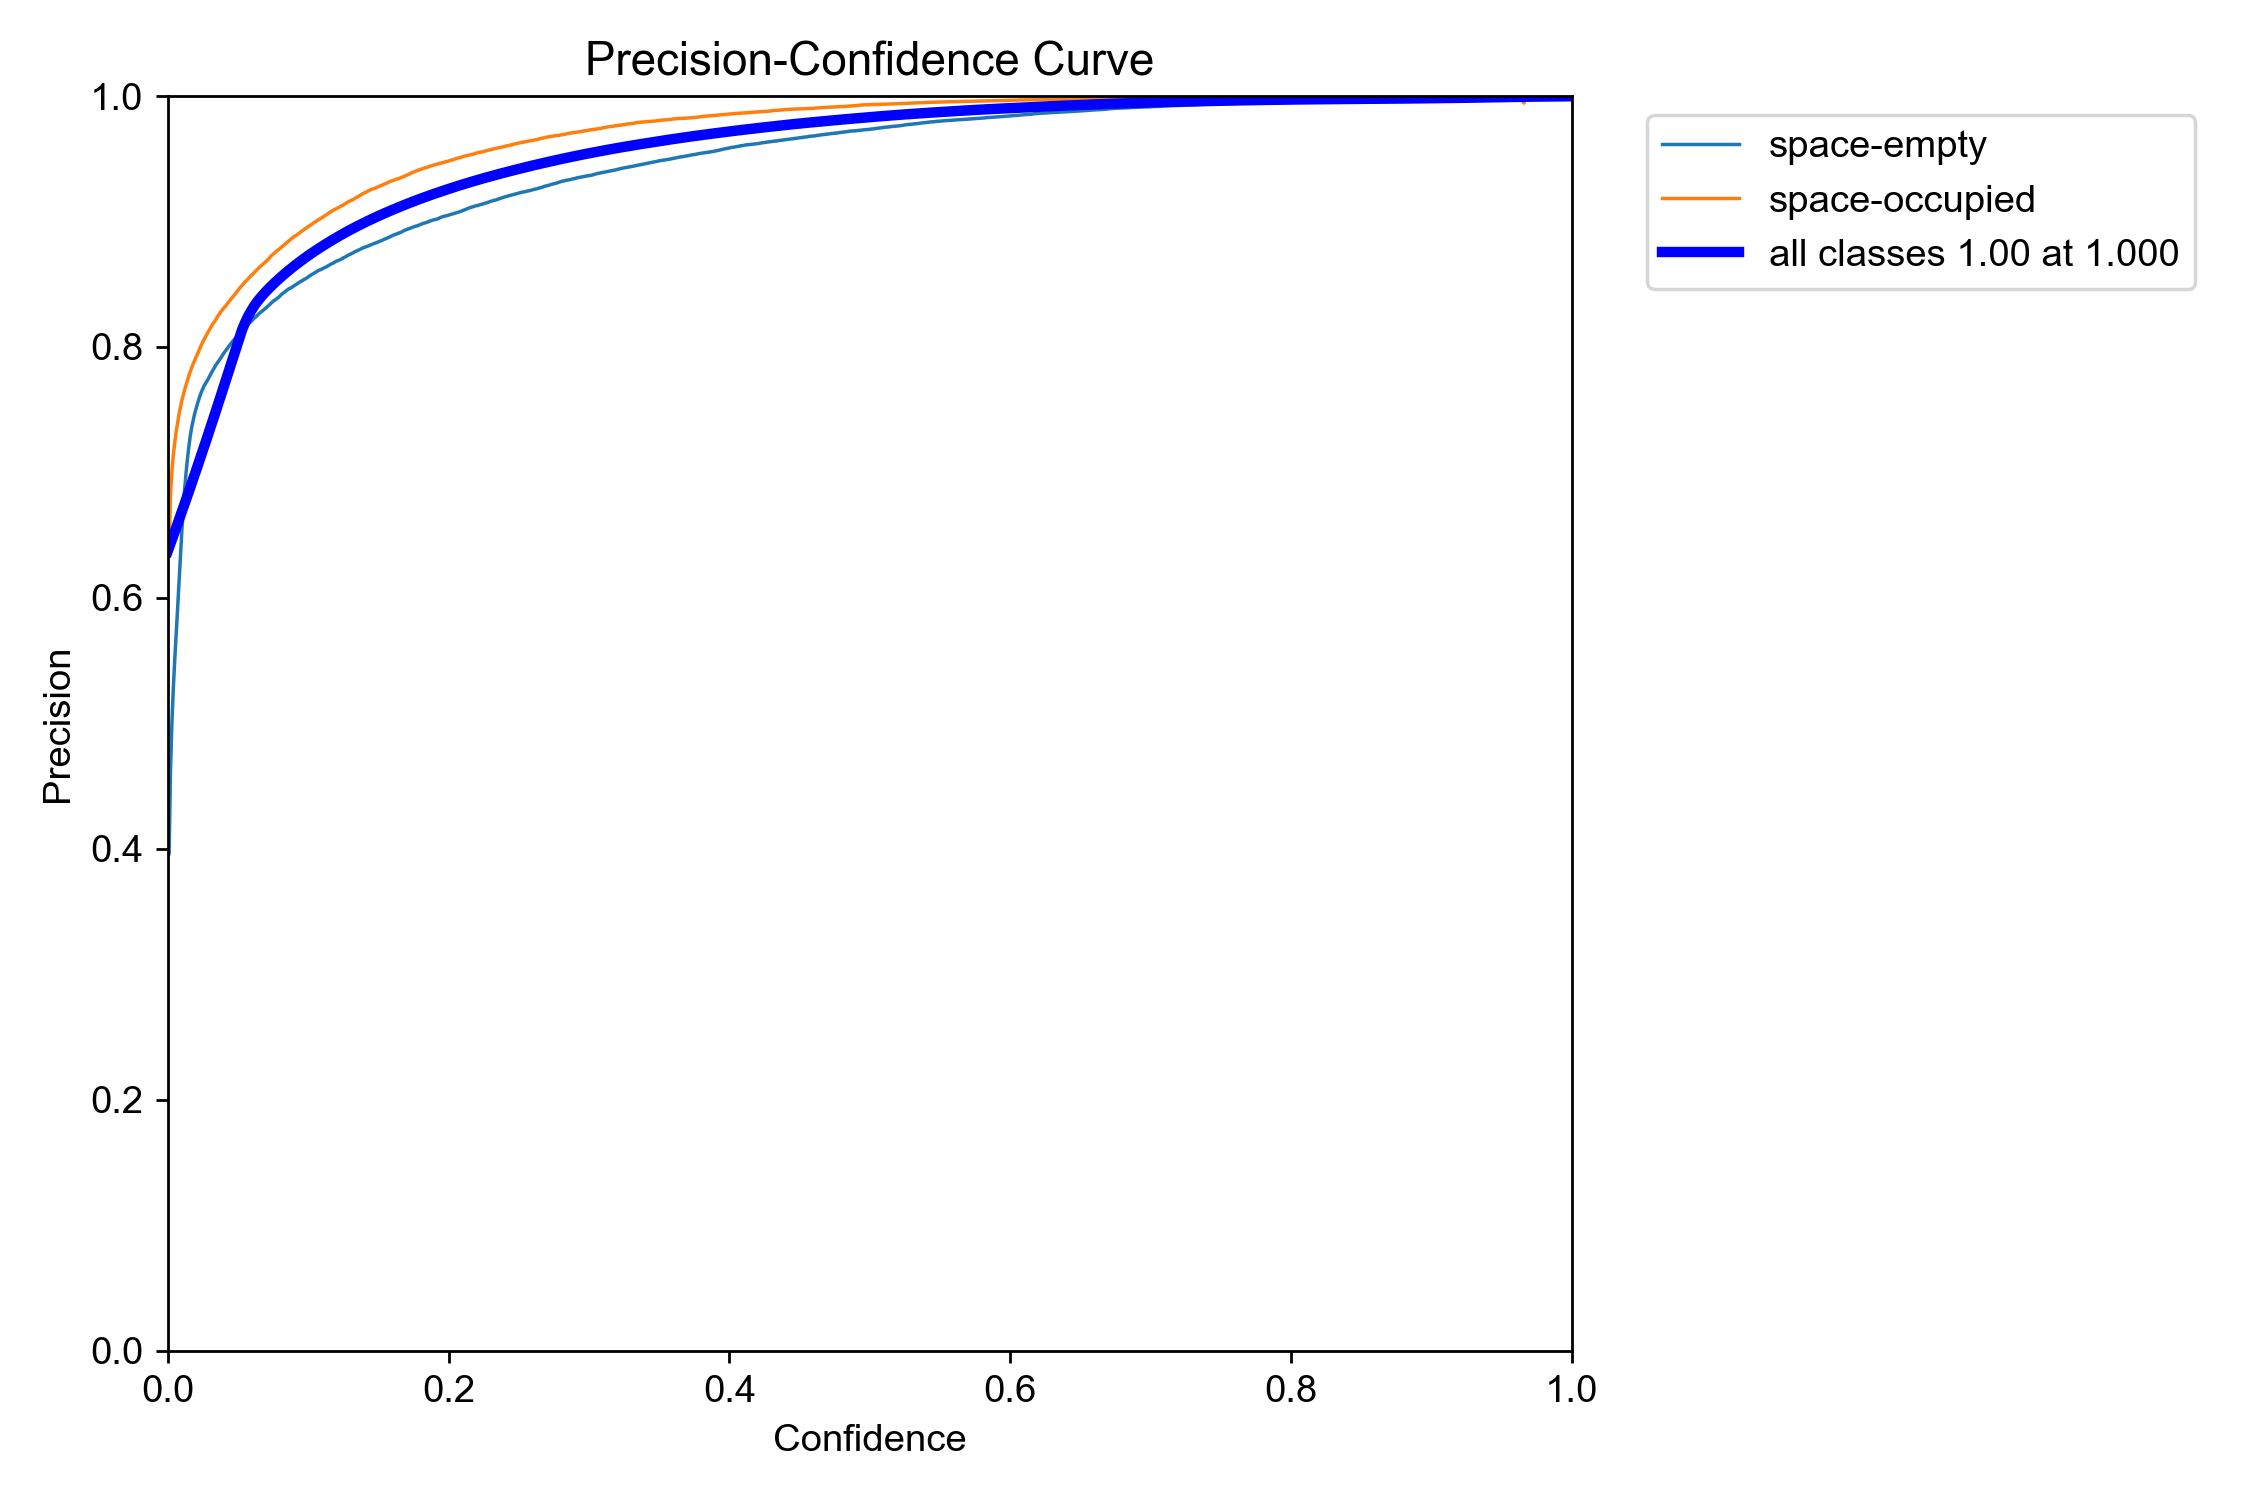

test_recall_curve.png


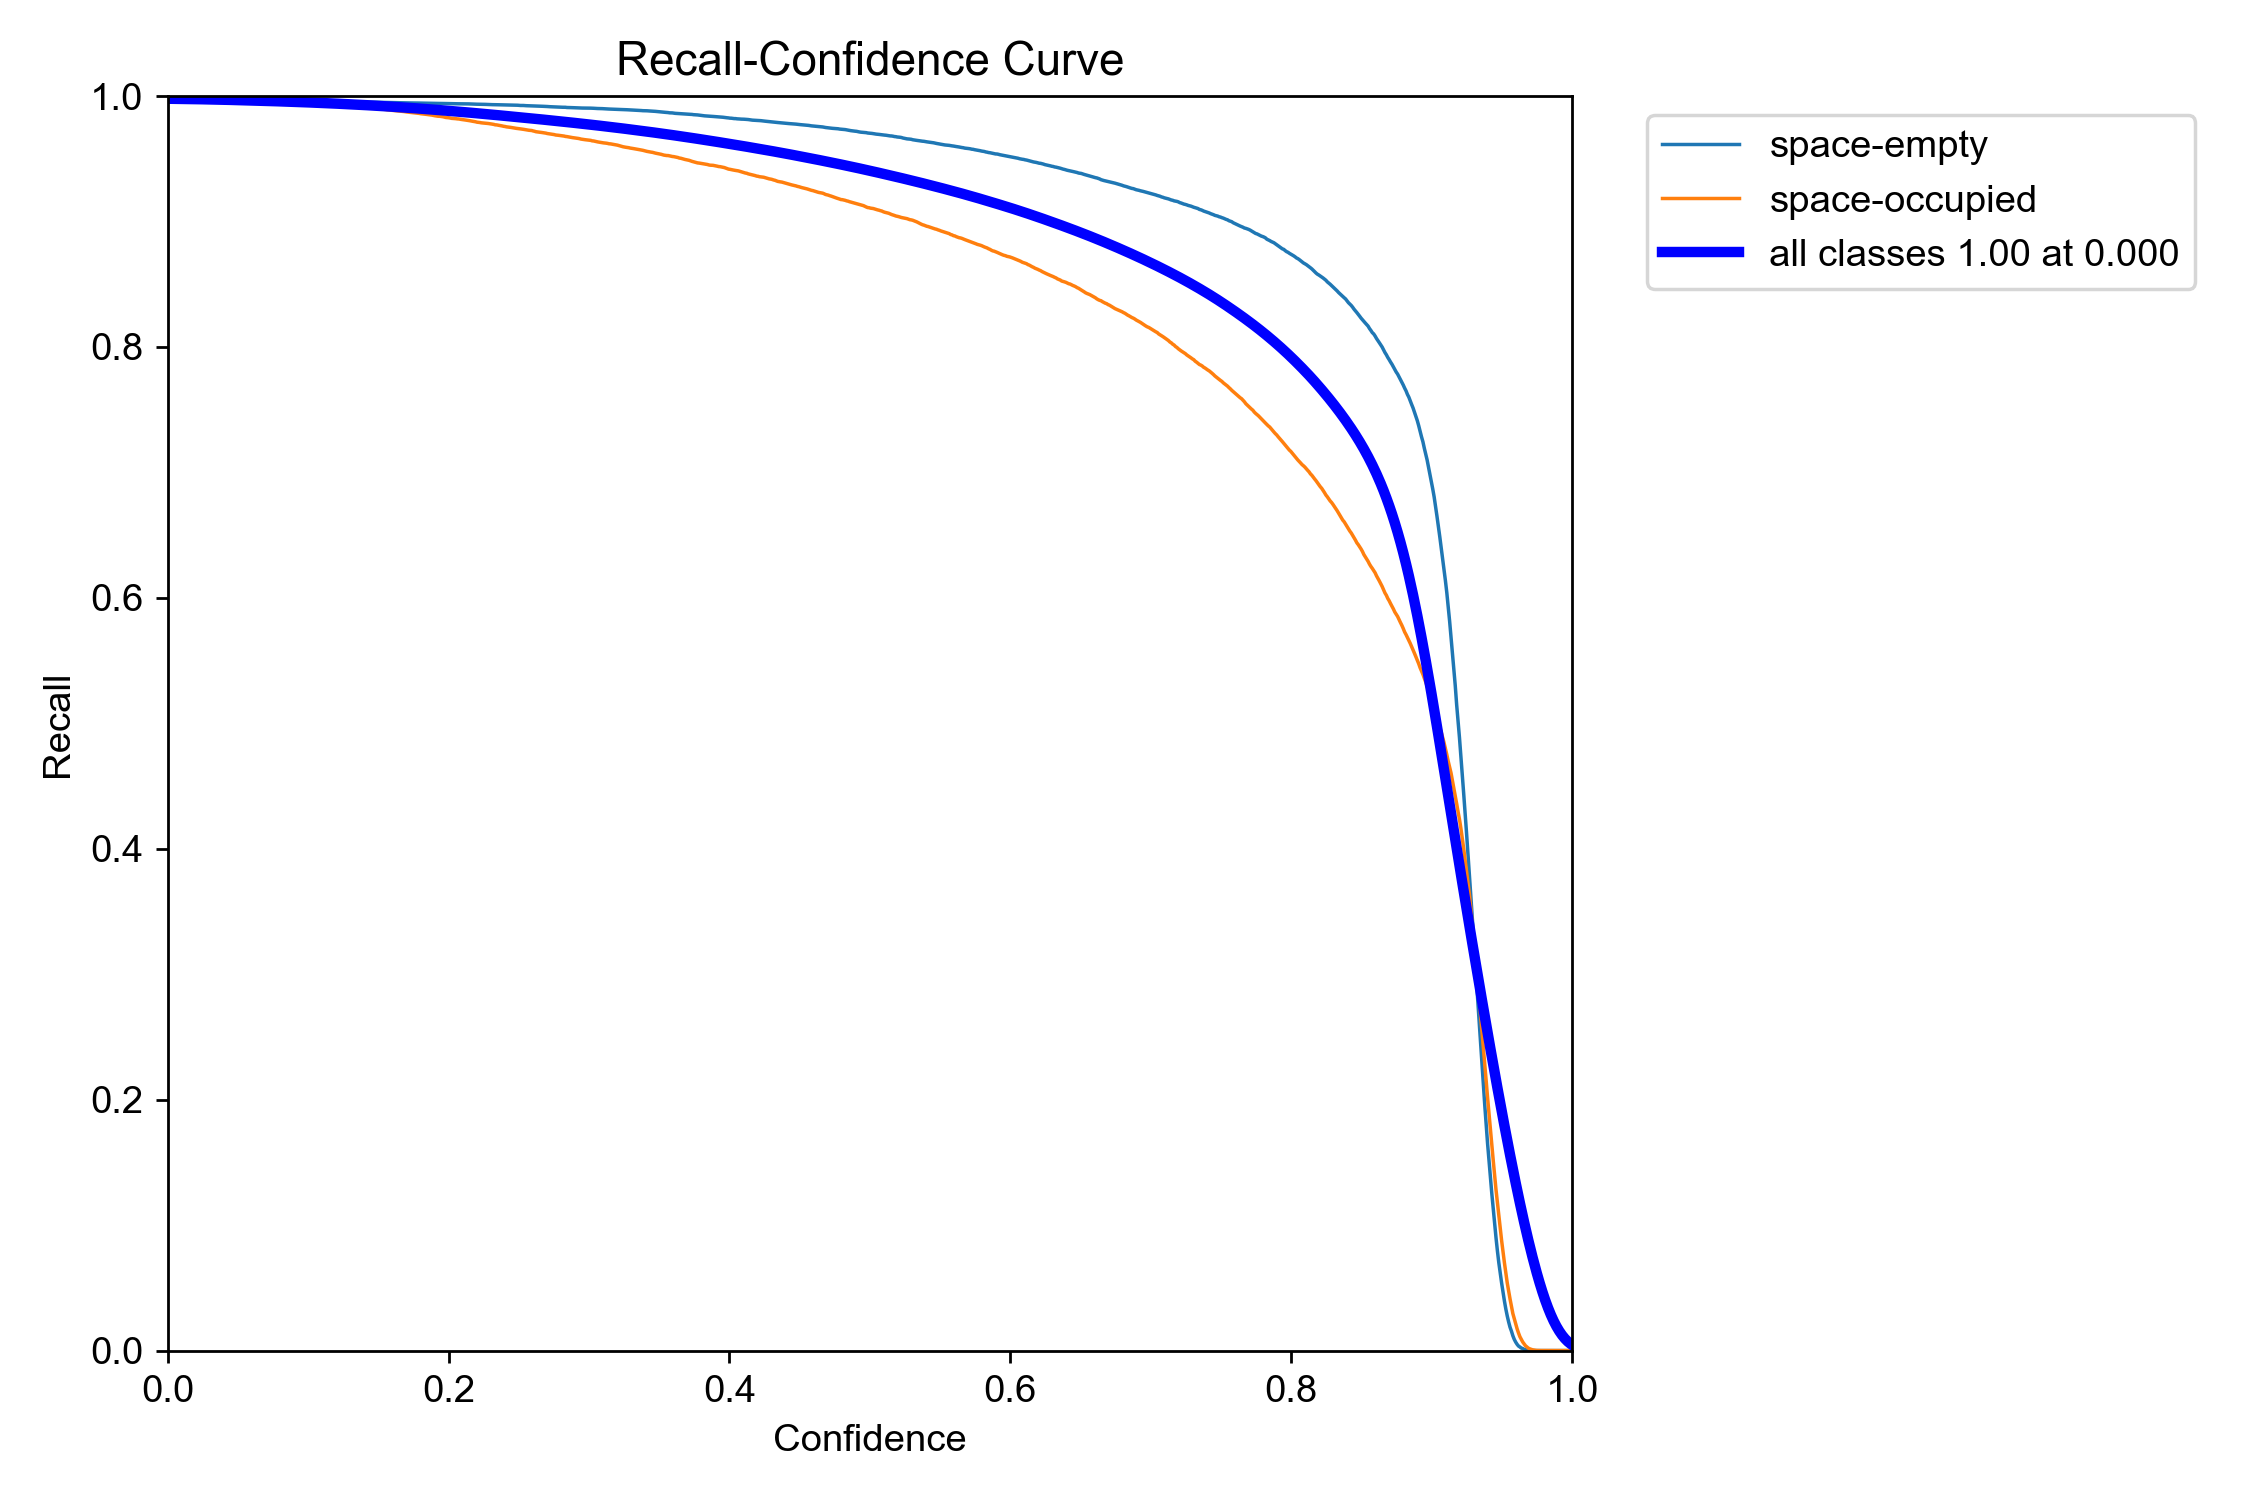

In [4]:
plot_files = [
    "test_confusion_matrix.png",
    "test_confusion_matrix_normalized.png",
    "test_pr_curve.png",
    "test_f1_curve.png",
    "test_precision_curve.png",
    "test_recall_curve.png",
]

for file_name in plot_files:
    path = PLOTS_DIR / file_name
    if path.exists():
        print(file_name)
        display(Image(filename=str(path)))
    else:
        print(f"Missing: {path}")

## 12. Example predictions

The model predictions visually confirm that the detector works well on dense parking lot scenes. It detects most parking spaces and generally assigns correct `empty`/`occupied` labels.

Some remaining issues include:

- occasional duplicate boxes,
- occasional missed spaces in very dense rows,
- occasional class confusion between empty and occupied spaces,
- noisy ground-truth labels in parts of the dataset.

2012-09-18_12_35_04_jpg.rf.854104452c86fa676498969fbb0b252e.jpg


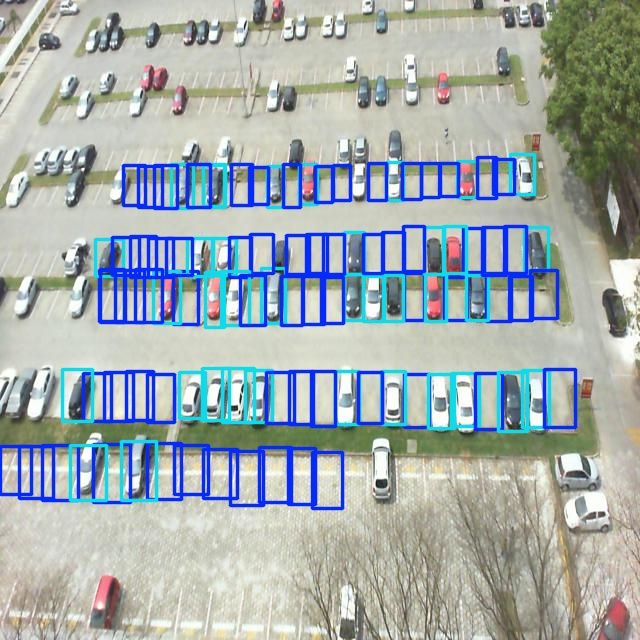

2012-09-28_10_11_09_jpg.rf.792ab6f8bef371e9ee380ec8d235290d.jpg


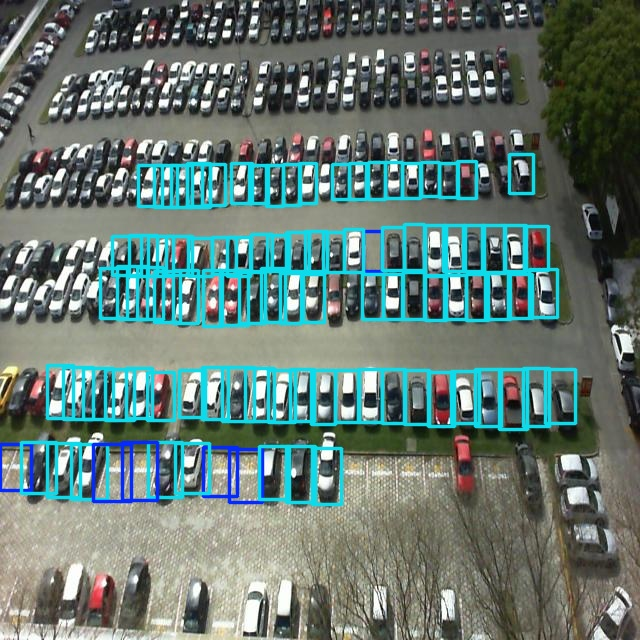

2012-10-11_14_11_48_jpg.rf.e797dad403bcaeced64eafbb2af5f20b.jpg


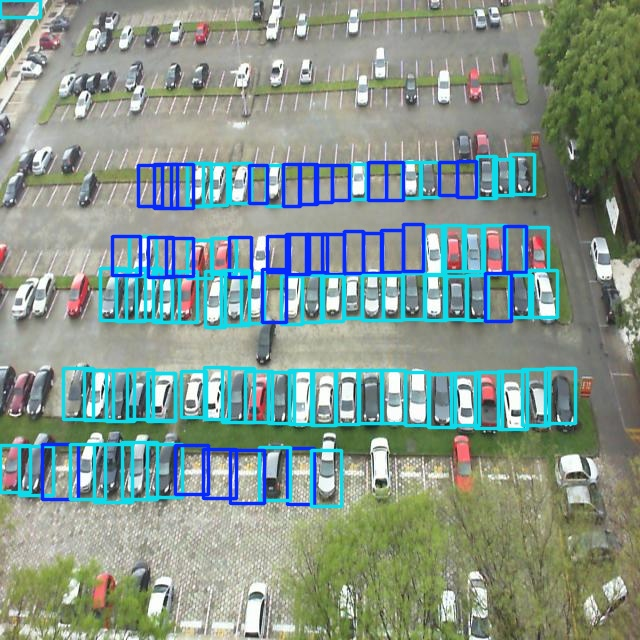

2012-10-25_19_13_53_jpg.rf.42e3c38c0adbf466d0d241b15c4df5c8.jpg


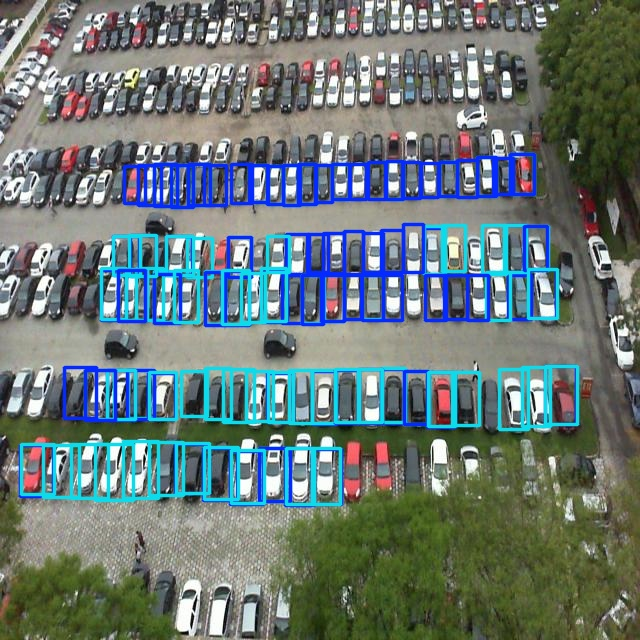

2012-10-27_12_10_53_jpg.rf.5c8c86f11bbde7ae5f2af8bce1640d88.jpg


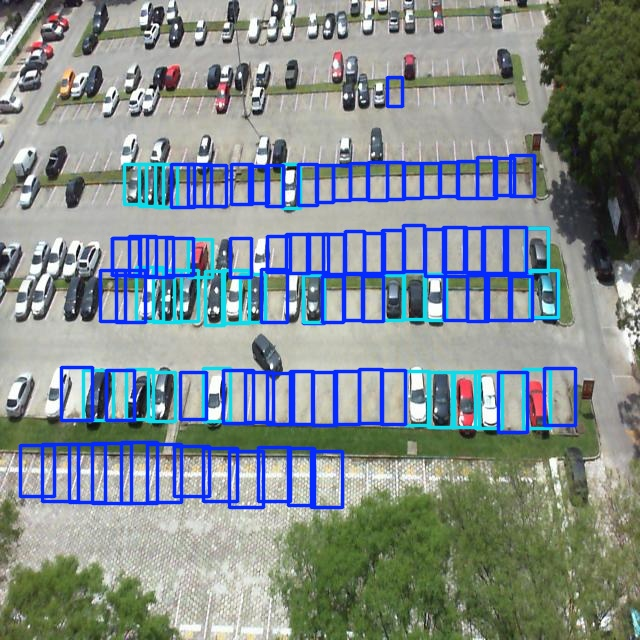

2012-10-29_11_48_08_jpg.rf.3c5ad417222c5544f4a9fbf46e6ba66e.jpg


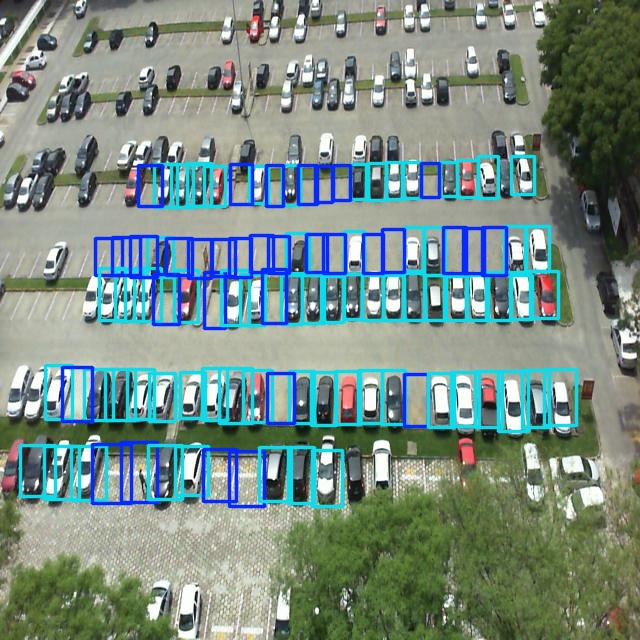

2012-11-09_19_22_08_jpg.rf.06b1ebe49a54e7bae8a2e30d7ba47b73.jpg


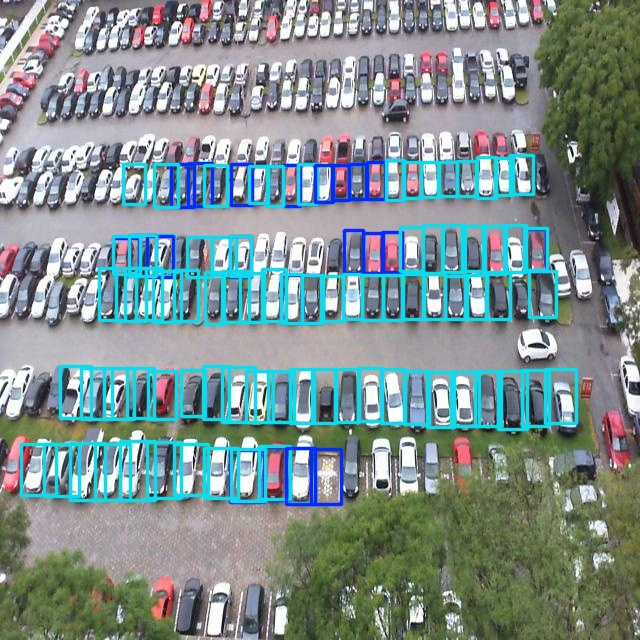

2012-12-26_10_15_05_jpg.rf.86b0d2d3d70add502fde315aa3c92702.jpg


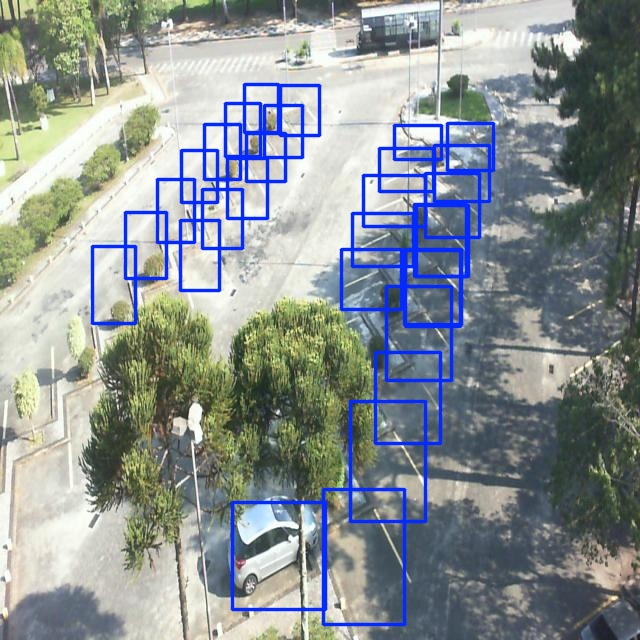

2013-01-17_12_05_08_jpg.rf.a7c10b63eddf94fff9d6c5a805cd5230.jpg


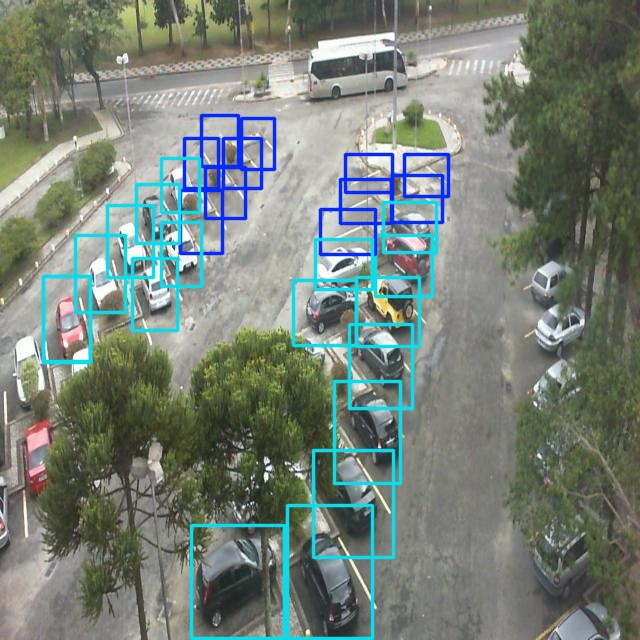

2013-03-18_15_15_10_jpg.rf.810984b21a9520acbe0ec1532896b186.jpg


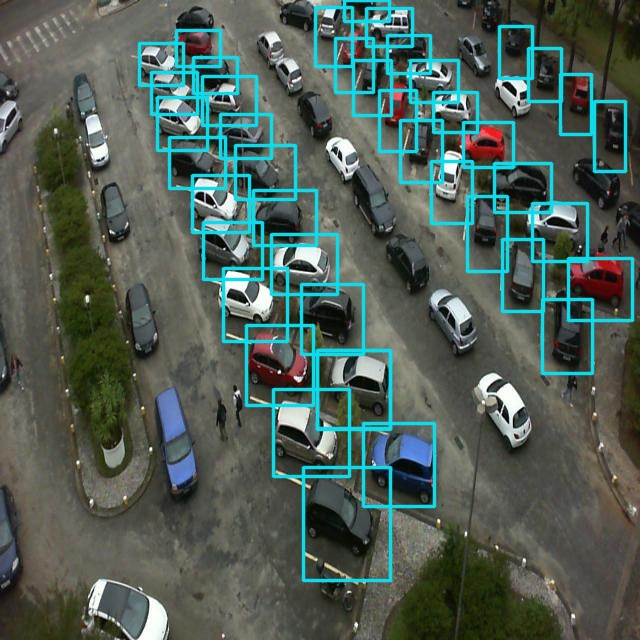

In [5]:
prediction_paths = sorted(PREDICTIONS_DIR.glob("*.jpg"))[:10]

if not prediction_paths:
    print(f"No prediction images found in {PREDICTIONS_DIR}")
else:
    for path in prediction_paths:
        print(path.name)
        display(Image(filename=str(path)))

## 13. Main observations

The baseline performs very well on the test set:

- `mAP@50 = 0.991`
- `mAP@50-95 = 0.866`
- precision and recall are both around `0.97`

The model is slightly more recall-oriented for `space-empty` and slightly more precision-oriented for `space-occupied`:

- `space-empty`: higher recall, lower precision
- `space-occupied`: higher precision, lower recall

This means the model finds almost all empty spaces, but may occasionally over-predict them. For occupied spaces, the model is very precise, but misses slightly more examples.

## 14. Limitations

The baseline has several limitations:

1. **Training did not finish all planned epochs.**  
   The process was killed with exit code `137`, likely due to memory pressure. The final model is based on the best checkpoint from the last fully validated epoch.

2. **Dataset label noise.**  
   During visual inspection, some `empty`/`occupied` labels appeared to be incorrect.

3. **Zero-annotation images were removed.**  
   Around 2% of images had no annotations. These were skipped because some still contained visible parking spaces.

4. **Single model and single training configuration.**  
   No extensive hyperparameter search was performed.

5. **Potential similarity between scenes.**  
   Since PKLot contains repeated camera viewpoints, train/validation/test scenes may be visually similar, which can contribute to high performance.

## 15. Conclusion

The YOLO26n baseline successfully solves the parking space detection and occupancy classification task.

Despite the interrupted training, the best checkpoint achieved strong results on the test set:

- high localization quality,
- high recall,
- high precision,
- strong performance for both `space-empty` and `space-occupied`.

This model is a solid baseline for future experiments. Possible next steps include:

- training with a safer memory configuration for more epochs,
- trying `imgsz=640` for faster training,
- comparing against a larger YOLO model,
- adding better filtering/cleaning for noisy labels,
- evaluating generalization across different parking lots or weather conditions.